# P11.1 Implement simulation of SIS model on ER graph. Compare results with our analytical findings. [2P]

Estimated <k> ≈ 29.961
Mean-field beta_c = gamma/<k> ≈ 0.0167


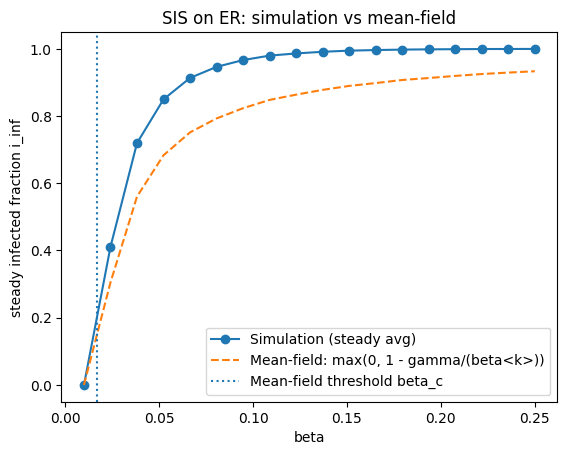

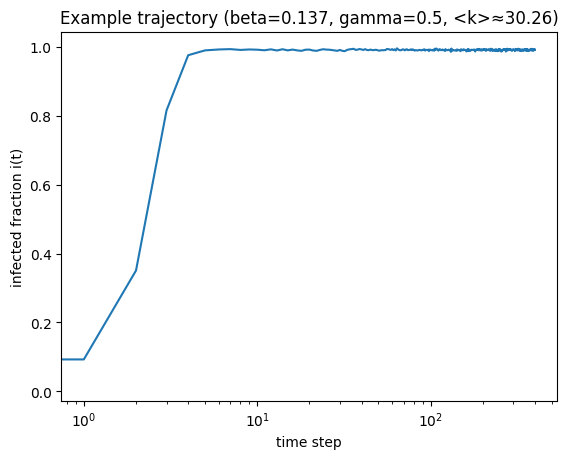

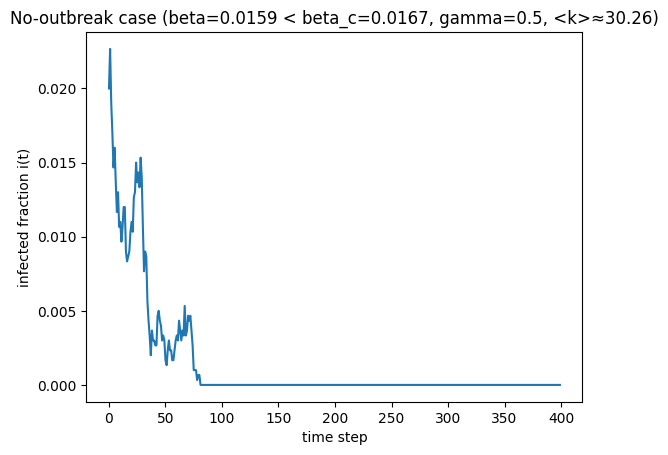

In [1]:
import numpy as np
import matplotlib.pyplot as plt


import networkx as nx


# I don't know what is the actual definition and proper approach. Whether we use 
def sis_step_no_same_step_reinfection(adj_list, infected, beta, gamma, rng):
    """
    Synchronous SIS update that does NOT allow a node infected at time t
    to recover and be re-infected within the same time step.
    """
    N = infected.size

    new_infected = infected.copy()
    susceptible_at_t = ~infected

    for u in range(N):
        if not susceptible_at_t[u]:
            continue
        m = 0
        for v in adj_list[u]:
            if infected[v]:
                m += 1
        if m > 0:
            p_inf = 1.0 - (1.0 - beta) ** m
            if rng.random() < p_inf:
                new_infected[u] = True

    recov = rng.random(N) < gamma
    new_infected[infected & recov] = False

    return new_infected




def sis_step(adj_list, infected, beta, gamma, rng):
    """
    One synchronous SIS step.
    infected: boolean array of shape (N,)
    """
    N = infected.size
    new_infected = infected.copy()

    recov = rng.random(N) < gamma
    new_infected[infected & recov] = False

    for u in range(N):
        if new_infected[u]:
            continue
        m = 0
        for v in adj_list[u]:
            if infected[v]:
                m += 1
        if m > 0:
            p_inf = 1.0 - (1.0 - beta) ** m
            if rng.random() < p_inf:
                new_infected[u] = True

    return new_infected



def run_sis_er(N=2000, p=0.01, beta=0.02, gamma=0.5, i0=0.05,
               T=300, burn_in=150, seed=0):
    """
    Build ER(N,p), run SIS, return time series of infected fraction and graph stats.
    """
    rng = np.random.default_rng(seed)

    G = nx.erdos_renyi_graph(N, p, seed=seed)
    adj_list = [list(G.neighbors(i)) for i in range(N)]
    degrees = np.array([len(adj_list[i]) for i in range(N)])
    k_mean = degrees.mean()

    infected = np.zeros(N, dtype=bool)
    initial = rng.choice(N, size=int(i0 * N), replace=False)
    infected[initial] = True

    frac = np.zeros(T)
    for t in range(T):
        frac[t] = infected.mean()
        infected = sis_step(adj_list, infected, beta, gamma, rng)

    steady = frac[burn_in:].mean() if burn_in < T else frac.mean()
    return frac, steady, k_mean


def mean_field_iinf(beta, gamma, k_mean):
    if beta <= 0:
        return 0.0
    return max(0.0, 1.0 - gamma / (beta * k_mean))


N = 3000
p = 0.01
gamma = 0.5
i0 = 0.02
T = 400
burn_in = 50

betas = np.linspace(0.01, 0.25, 18)
sim_iinf = []
mf_iinf = []
k_means = []

for idx, beta in enumerate(betas):
    frac, steady, k_mean = run_sis_er(
        N=N, p=p, beta=beta, gamma=gamma, i0=i0,
        T=T, burn_in=burn_in, seed=idx
    )
    sim_iinf.append(steady)
    mf_iinf.append(mean_field_iinf(beta, gamma, k_mean))
    k_means.append(k_mean)

k_mean_global = float(np.mean(k_means))
beta_c = gamma / k_mean_global

print(f"Estimated <k> ≈ {k_mean_global:.3f}")
print(f"Mean-field beta_c = gamma/<k> ≈ {beta_c:.4f}")

plt.figure()
plt.plot(betas, sim_iinf, marker="o", linestyle="-", label="Simulation (steady avg)")
plt.plot(betas, mf_iinf, linestyle="--", label="Mean-field: max(0, 1 - gamma/(beta<k>))")
plt.axvline(beta_c, linestyle=":", label="Mean-field threshold beta_c")
plt.xlabel("beta")
plt.ylabel("steady infected fraction i_inf")
plt.title("SIS on ER: simulation vs mean-field")
plt.legend()
plt.show()

beta_example = max(beta_c * 1.5, betas[len(betas)//2])
frac, steady, k_mean = run_sis_er(
    N=N, p=p, beta=beta_example, gamma=gamma, i0=i0,
    T=T, burn_in=burn_in, seed=123
)
plt.figure()
plt.plot(frac)
plt.xscale("log")
plt.xlabel("time step")
plt.ylabel("infected fraction i(t)")
plt.title(f"Example trajectory (beta={beta_example:.3f}, gamma={gamma}, <k>≈{k_mean:.2f})")
plt.show()


beta_example_2 = 0.95 * beta_c

frac, steady, k_mean = run_sis_er(
    N=N, p=p, beta=beta_example_2, gamma=gamma, i0=i0,
    T=T, burn_in=burn_in, seed=123
)

plt.figure()
plt.plot(frac)
plt.xlabel("time step")
plt.ylabel("infected fraction i(t)")
plt.title(f"No-outbreak case (beta={beta_example_2:.4f} < beta_c={beta_c:.4f}, gamma={gamma}, <k>≈{k_mean:.2f})")
plt.show()
    

In [2]:
def run_sis_on_graph(G, beta, gamma, i0=0.01, T=2000, burn_in=1000, seed=0):
    rng = np.random.default_rng(seed)

    N = G.number_of_nodes()
    adj_list = [list(G.neighbors(i)) for i in range(N)]
    deg = np.array([len(adj_list[i]) for i in range(N)], dtype=float)

    k_mean = deg.mean()
    k2_mean = (deg**2).mean()

    infected = np.zeros(N, dtype=bool)
    initial = rng.choice(N, size=max(1, int(i0 * N)), replace=False)
    infected[initial] = True

    frac = np.zeros(T)
    for t in range(T):
        frac[t] = infected.mean()
        infected = sis_step_no_same_step_reinfection(adj_list, infected, beta, gamma, rng)

    steady = frac[burn_in:].mean() if burn_in < T else frac.mean()
    return frac, steady, k_mean, k2_mean


def lambda_c_from_mf(k_mean, k2_mean):
    # lecture: lambda_c = <k>/<k^2>
    return k_mean / k2_mean if k2_mean > 0 else np.inf

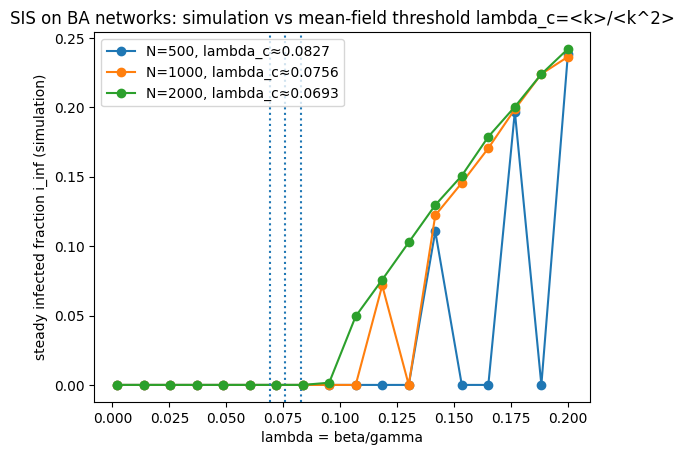

In [ ]:
gamma = 0.2
m = 3
i0 = 0.01
T = 2500
burn_in = 1500

#Ns = [1000, 3000, 10000]
Ns = [500, 1000, 2000]
lambdas = np.linspace(0.002, 0.20, 18)

plt.figure()
for N in Ns:
    G = nx.barabasi_albert_graph(N, m, seed=1)

    deg = np.array([d for _, d in G.degree()], dtype=float)
    k_mean = deg.mean()
    k2_mean = (deg**2).mean()
    lam_c = lambda_c_from_mf(k_mean, k2_mean)

    sim_iinf = []
    for idx, lam in enumerate(lambdas):
        beta = lam * gamma
        _, steady, _, _ = run_sis_on_graph(
            G, beta=beta, gamma=gamma, i0=i0, T=T, burn_in=burn_in, seed=idx
        )
        sim_iinf.append(steady)

    plt.plot(lambdas, sim_iinf, marker="o", linestyle="-", label=f"N={N}, lambda_c≈{lam_c:.4f}")

    plt.axvline(lam_c, linestyle=":")

plt.xlabel("lambda = beta/gamma")
plt.ylabel("steady infected fraction i_inf (simulation)")
plt.title("SIS on BA networks: simulation vs mean-field threshold lambda_c=<k>/<k^2>")
plt.legend()
plt.show()

# P11.3 Implement simulation of different than SIS agent-based model. Discuss obtained results. [2P]

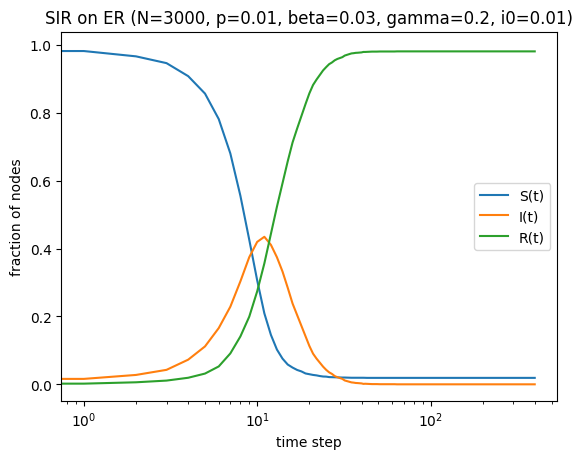

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def sir_step(adj_list, infected, recovered, beta, gamma, rng):
    """

    Per step:
      S -> I with prob 1-(1-beta)^m where m=# infected neighbors at time t
      I -> R with prob gamma
      R stays R
    """
    N = infected.size
    susceptible = ~(infected | recovered)

    infected_next = infected.copy()
    recovered_next = recovered.copy()

    infected_at_t = infected
    for u in range(N):
        if not susceptible[u]:
            continue
        m = 0
        for v in adj_list[u]:
            if infected_at_t[v]:
                m += 1
        if m > 0:
            p_inf = 1.0 - (1.0 - beta) ** m
            if rng.random() < p_inf:
                infected_next[u] = True

    recov = rng.random(N) < gamma
    to_recover = infected_at_t & recov
    infected_next[to_recover] = False
    recovered_next[to_recover] = True

    return infected_next, recovered_next


def run_sir_er(N=3000, p=0.01, beta=0.03, gamma=0.2, i0=0.01, T=400, seed=0):
    rng = np.random.default_rng(seed)

    G = nx.erdos_renyi_graph(N, p, seed=seed)
    adj_list = [list(G.neighbors(i)) for i in range(N)]

    infected = np.zeros(N, dtype=bool)
    recovered = np.zeros(N, dtype=bool)

    initial = rng.choice(N, size=max(1, int(i0 * N)), replace=False)
    infected[initial] = True

    s_frac = np.zeros(T)
    i_frac = np.zeros(T)
    r_frac = np.zeros(T)

    for t in range(T):
        s_frac[t] = np.mean(~(infected | recovered))
        i_frac[t] = infected.mean()
        r_frac[t] = recovered.mean()

        if infected.sum() == 0:
            s_frac[t:] = s_frac[t]
            i_frac[t:] = 0.0
            r_frac[t:] = r_frac[t]
            break

        infected, recovered = sir_step(adj_list, infected, recovered, beta, gamma, rng)

    return s_frac, i_frac, r_frac


N = 3000
p = 0.01
beta = 0.03
gamma = 0.2
i0 = 0.01
T = 400
seed = 123

s, i, r = run_sir_er(N=N, p=p, beta=beta, gamma=gamma, i0=i0, T=T, seed=seed)

plt.figure()
plt.plot(s, label="S(t)")
plt.plot(i, label="I(t)")
plt.plot(r, label="R(t)")
plt.xlabel("time step")
plt.ylabel("fraction of nodes")
plt.title(f"SIR on ER (N={N}, p={p}, beta={beta}, gamma={gamma}, i0={i0})")
plt.legend()
plt.xscale("log")
plt.show()


# P11.4 Modify classical voter model that it takes into account additional effects (e.g. propaganda, agent ideology, etc.). [2P]

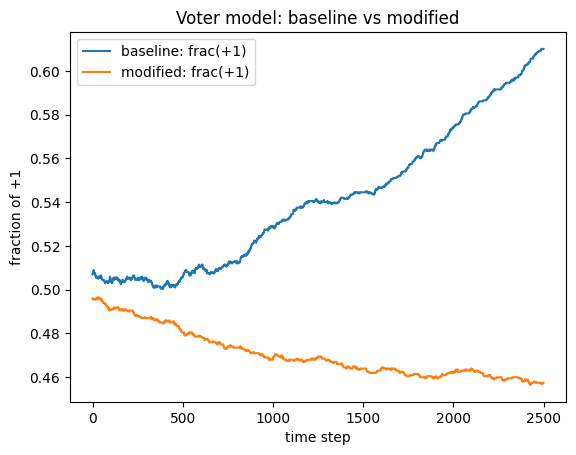

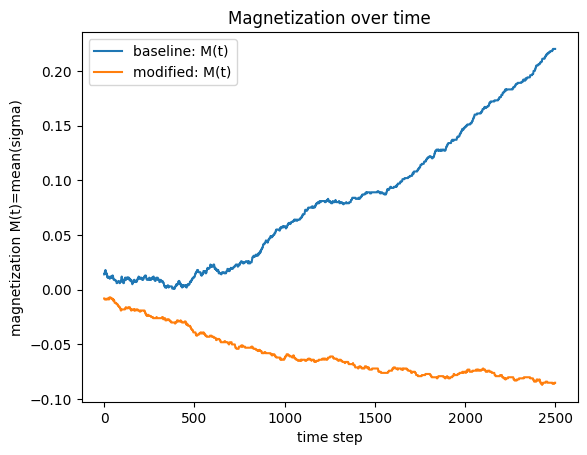

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


def voter_step_baseline(adj_list, sigma, rng):
    N = len(sigma)
    i = rng.integers(N)
    m = 0
    for j in adj_list[i]:
        m += sigma[j]

    if m > 0:
        sigma[i] = 1
    elif m < 0:
        sigma[i] = -1
    return sigma


def voter_step_modified(adj_list, sigma, rng,
                        prop_dir=1, prop_strength=0.0,
                        ideology=None, ideol_strength=0.0,
                        stubborn=None,
                        noise=0.0,
                        zealot_mask=None):

    N = len(sigma)
    i = rng.integers(N)

    if zealot_mask is not None and zealot_mask[i]:
        return sigma

    if stubborn is not None and rng.random() < stubborn[i]:
        return sigma

    m = 0
    for j in adj_list[i]:
        m += sigma[j]

    ideol_i = 0.0 if ideology is None else ideology[i]

    h = m + prop_strength * prop_dir + ideol_strength * ideol_i

    if h > 0:
        new = 1
    elif h < 0:
        new = -1
    else:
        new = sigma[i]
    if noise > 0 and rng.random() < noise:
        new = -new

    sigma[i] = new
    return sigma


def simulate_voter(G, T=50000, seed=0, model="baseline", **kwargs):
    """
    Returns time series:
      frac_plus[t] = fraction of +1 at step t
      magnet[t] = mean sigma at step t
    """
    rng = np.random.default_rng(seed)
    N = G.number_of_nodes()
    adj_list = [list(G.neighbors(i)) for i in range(N)]

    sigma = rng.choice([-1, 1], size=N).astype(np.int8)

    frac_plus = np.zeros(T)
    magnet = np.zeros(T)

    for t in range(T):
        frac_plus[t] = np.mean(sigma == 1)
        magnet[t] = np.mean(sigma)

        if model == "baseline":
            sigma = voter_step_baseline(adj_list, sigma, rng)
        elif model == "modified":
            sigma = voter_step_modified(adj_list, sigma, rng, **kwargs)

    return frac_plus, magnet



N = 2000
p = 0.01
G = nx.erdos_renyi_graph(N, p, seed=1)

T = 2500

frac_b, mag_b = simulate_voter(G, T=T, seed=1, model="baseline")

rng = np.random.default_rng(123)
ideology = rng.uniform(-1, 1, size=N)
stubborn = rng.beta(a=5.0, b=2.0, size=N)

zealot_mask = np.zeros(N, dtype=bool)
zealot_mask[rng.choice(N, size=int(0.02 * N), replace=False)] = True

frac_m, mag_m = simulate_voter(
    G, T=T, seed=2, model="modified",
    prop_dir=-1, prop_strength=1.0,
    ideology=ideology, ideol_strength=5,
    stubborn=stubborn,
    noise=0.05,
    zealot_mask=zealot_mask
)

plt.figure()
plt.plot(frac_b, label="baseline: frac(+1)")
plt.plot(frac_m, label="modified: frac(+1)")
plt.xlabel("time step")
plt.ylabel("fraction of +1")
plt.title("Voter model: baseline vs modified")
plt.legend()
plt.show()

plt.figure()
plt.plot(mag_b, label="baseline: M(t)")
plt.plot(mag_m, label="modified: M(t)")
plt.xlabel("time step")
plt.ylabel("magnetization M(t)=mean(sigma)")
plt.title("Magnetization over time")
plt.legend()
plt.show()


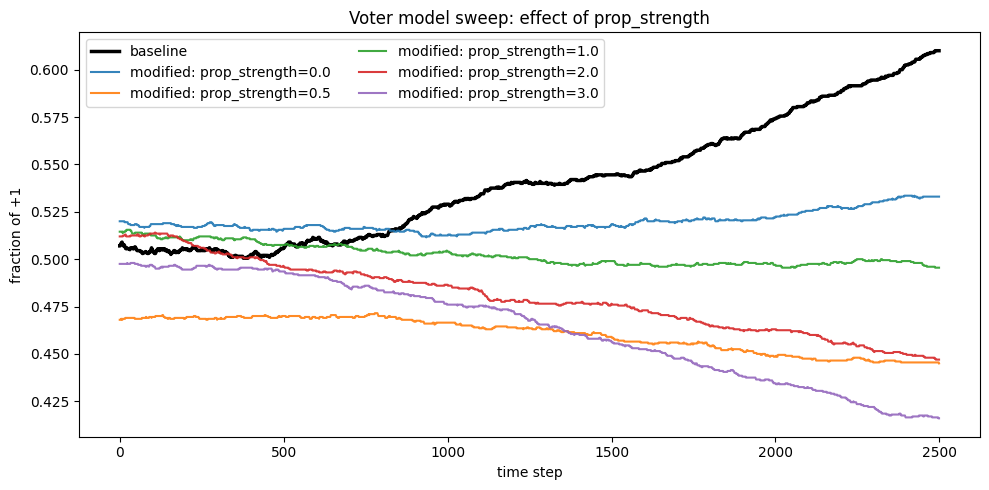

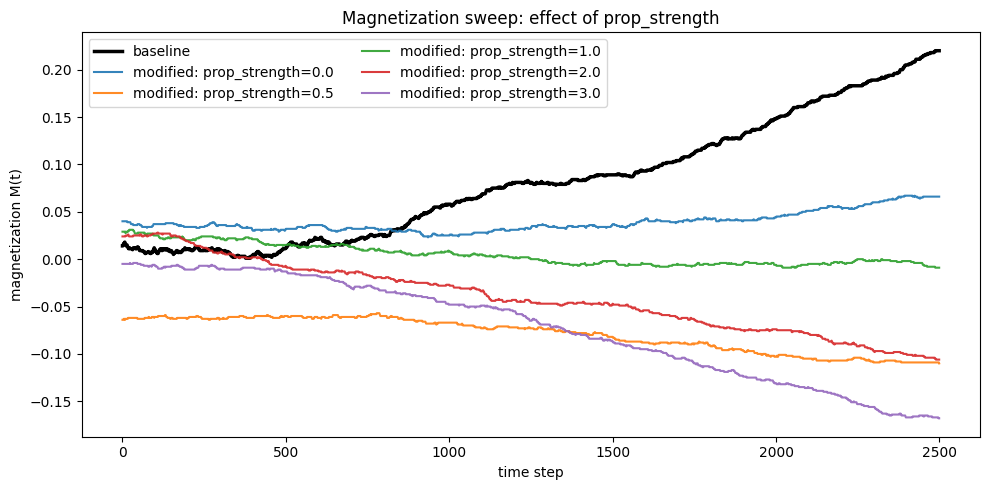

In [8]:
prop_strength_values = [0.0, 0.5, 1.0, 2.0, 3.0]

base_kwargs = dict(
    model="modified",
    prop_dir=-1,
    ideology=ideology,
    ideol_strength=5,
    stubborn=stubborn,
    noise=0.05,
    zealot_mask=zealot_mask
)

frac_b, mag_b = simulate_voter(G, T=T, seed=1, model="baseline")

results = []
for k, ps in enumerate(prop_strength_values):
    frac_m, mag_m = simulate_voter(
        G, T=T, seed=100 + k,
        prop_strength=ps,
        **base_kwargs
    )
    results.append((ps, frac_m, mag_m))

plt.figure(figsize=(10, 5))
plt.plot(frac_b, color="black", linewidth=2.5, label="baseline")
for ps, frac_m, _ in results:
    plt.plot(frac_m, alpha=0.9, label=f"modified: prop_strength={ps}")
plt.xlabel("time step")
plt.ylabel("fraction of +1")
plt.title("Voter model sweep: effect of prop_strength")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(mag_b, color="black", linewidth=2.5, label="baseline")
for ps, _, mag_m in results:
    plt.plot(mag_m, alpha=0.9, label=f"modified: prop_strength={ps}")
plt.xlabel("time step")
plt.ylabel("magnetization M(t)")
plt.title("Magnetization sweep: effect of prop_strength")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
